# Configuración 2: 1D-CNN (a) + PINN (b) + predictor multi-paso (c)

**Anexo de código del TFM.** Pronóstico de crecimiento de grietas por fatiga (PHM Data Challenge 2019).
Carlos J. Bravo I.

La Configuración 2 no cambia la red. Hereda intacto el estimador de la Configuración 1, con la misma
arquitectura, los mismos pesos y el mismo entrenamiento, y sustituye únicamente el motor de
extrapolación: donde la Configuración 1 emplea la solución analítica cerrada de la ley de Paris, ésta
integra numéricamente la ecuación diferencial paso a paso.

El componente añadido se evalúa en dos variantes, que miden cosas distintas.

| Variante | Motor de extrapolación | Lo que mide |
|---|---|---|
| **Config 2** | integración explícita sobre el bloque de carga real | la aportación de integrar paso a paso, por sí sola |
| **Config 2b** | integración explícita con retardo de Wheeler (*p* = 1.43 fijado a priori) | la aportación de modelar la interacción de cargas |

El entrenamiento se realiza una sola vez y los tres motores de extrapolación se aplican sobre el
mismo ancla. Es lo que permite atribuir las diferencias entre filas al motor y no a la varianza entre
semillas.

## Contenido

| Apartado | Contenido |
|---|---|
| 1 | El componente añadido |
| 2 | Los dos integradores |
| 3 | El exponente del modelo de retardo |
| 4 | Entrenamiento e inferencia |
| 5 | Evaluación de las dos variantes |
| 6 | Comparación con la Configuración 1 |
| 7 | La naturaleza del factor de retardo |
| 8 | El alcance del retardo frente a lo que T8 necesita |
| 9 | Conclusiones |
| 10 | Limitaciones |

Los pesos entrenados se guardan en `models/` y se reutilizan. Como la siembra está fijada, volver a entrenar solo cambia el tiempo de ejecución, no el resultado; `ENTRENAR_DE_NUEVO = True` en la primera celda de código lo rehace ignorando lo guardado.

### Arquitectura

El diagrama siguiente sitúa los componentes de esta configuración. Respecto de la Configuración 1 cambia una sola pieza, enmarcada con trazo discontinuo: el predictor multi-paso (c), que sustituye la solución cerrada por la integración RK4 del bloque de carga real.

![Arquitectura de la Configuración 2](../docs/img/arquitectura_config2.png)

In [ ]:
import sys, time, warnings
from pathlib import Path

warnings.filterwarnings("ignore")
RAIZ = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / "config1_cnn_pinn" / "model.py").is_file())
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display

torch.set_num_threads(4)
pd.set_option("display.width", 210)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True, "grid.alpha": .3,
                     "axes.spines.top": False, "axes.spines.right": False})

from config1_cnn_pinn.data import build_specimen_batches, load_labels
from config1_cnn_pinn.evaluate import ABLATION, n_observed_nonzero
from config1_cnn_pinn.physics import equivalent_stress_range, fit_log_c, propagate_mm
from config1_cnn_pinn.train import Config, TRAIN_POOL, evaluate_ensemble, train_ensemble
from config2_rk4.integrator import integrate_block_rk4
from config2_rk4.retardation import (YIELD_STRENGTH_MPA, PLANE_STRESS_ALPHA,
                                     block_rate_with_retardation, integrate_with_retardation,
                                     k_max, plastic_zone_m, retardation_summary, wheeler_phi)
from physics_calibration.data import load_curve
from physics_calibration.objectives import phm_penalty
from src.referencias_phm import PUBLICADO, REPLICA

MARCA_DE_AGUA = "Carlos J. Bravo (2026)"


def marca_de_agua(fig, texto=MARCA_DE_AGUA):
    fig.text(0.995, 0.004, texto, fontsize=8, color="0.45", alpha=0.38,
             ha="right", va="bottom", fontweight="bold")
    return fig


WHEELER_P = 1.43
INICIO = time.perf_counter()
print(f"Exponente del modelo de retardo, fijado a priori: p = {WHEELER_P}")
print(f"Límite elástico del 2024-T3 en chapa fina       : {YIELD_STRENGTH_MPA} MPa")
print(f"Constreñimiento en tensión plana                : alpha = {PLANE_STRESS_ALPHA}")

from src.pesos_entrenados import cargar_o_entrenar, inventario

ENTRENAR_DE_NUEVO = False


## 1. El componente añadido

La solución analítica de la Configuración 1 arrastra dos limitaciones que sólo un integrador
explícito puede levantar.

1. **El espectro real, segmento a segmento.** El bloque de carga de T8 son 500 ciclos a 90.00 MPa
   seguidos de 500 a 100.21 MPa. La forma cerrada los colapsa en un único rango de tensión
   equivalente y congela la longitud de grieta dentro del bloque; la integración explícita resuelve
   cada segmento con la longitud de grieta que hay en ese instante.
2. **La interacción de cargas.** Es el fenómeno que la forma cerrada no puede representar en
   absoluto: tras un ciclo de sobrecarga, la zona plástica residual en la punta mantiene la grieta
   parcialmente cerrada y la propagación se retarda durante los ciclos siguientes. Al depender de la
   historia de carga y no sólo del estado, exige integrar paso a paso.

### 1.1 La anomalía de T8

La tasa medida de T8 se desacelera al pasar de la ventana observada a la ventana ciega, cuando la ley
de Paris con coeficiente constante exige que acelere al crecer la grieta. T7, sometida a amplitud
constante, sí acelera, y por eso la forma cerrada le basta.

In [2]:
filas = []
for nombre in ("T7", "T8"):
    cur = load_curve(nombre)
    a, n = np.asarray(cur.crack_mm), np.asarray(cur.cycles)
    tasas_um_por_ciclo = np.diff(a) / np.diff(n) * 1e3
    corte = n_observed_nonzero(nombre)
    obs, ciega = tasas_um_por_ciclo[:corte - 1], tasas_um_por_ciclo[corte - 1:]
    filas.append({
        "espécimen": nombre,
        "espectro": "variable" if cur.is_variable_amplitude else "constante",
        "tasa en la ventana observada (µm/ciclo)": round(float(np.mean(obs)), 3) if len(obs) else np.nan,
        "tasa en la ventana ciega (µm/ciclo)": round(float(np.mean(ciega)), 3),
        "razón ciega/observada": round(float(np.mean(ciega) / np.mean(obs)), 2) if len(obs) else np.nan,
    })
display(pd.DataFrame(filas))
r8 = [f for f in filas if f["espécimen"] == "T8"][0]["razón ciega/observada"]
print(f"T8 se frena x{1/r8:.2f} al entrar en la ventana ciega.")

,espécimen,espectro,tasa en la ventana observada (µm/ciclo),tasa en la ventana ciega (µm/ciclo),razón ciega/observada
0,T7,constante,0.361,0.509,1.41
1,T8,variable,0.273,0.150,0.55


T8 se frena x1.82 al entrar en la ventana ciega.


La ley de Paris con coeficiente constante exige que esa razón sea mayor que 1, porque la grieta
acelera a medida que crece. T8 la tiene por debajo de 1: se frena justo donde la ley exige acelerar,
y ésa es la anomalía que el componente añadido pretende explicar.

La razón se define como el cociente entre la media de las tasas por intervalo en la ventana ciega y
esa misma media en la ventana observada. Otras ventanas de referencia, contadas desde la última ancla
o de extremo a extremo, dan cifras distintas que no son comparables con ésta.

## 2. Los dos integradores

La red no cambia en absoluto. Lo que cambia es la función que convierte el ancla, que es la última
estimación obtenida con señal, en la curva extrapolada.

**Integración explícita sobre el bloque real.** La tasa instantánea es la media ponderada por ciclos
de las tasas de cada segmento del espectro, evaluadas en la longitud de grieta actual, y se integra
con el método de Runge-Kutta de cuarto orden.

**Integración con retardo.** Añade el factor φ ∈ [0, 1] que frena los segmentos de menor amplitud
mientras la punta de la grieta sigue dentro de la zona plástica que dejó la sobrecarga:

$$r_y = \frac{1}{\alpha\pi}\left(\frac{K_{\max}}{\sigma_y}\right)^2, \qquad
\varphi = \left(\frac{r_y}{a_{ol} + r_{ol} - a}\right)^{p} \;\text{si}\; a + r_y < a_{ol}+r_{ol},
\;\text{y}\; \varphi = 1 \;\text{si no}$$

Se adopta la formulación de Wheeler (1972) porque tiene un solo parámetro libre. Ningún espécimen de
entrenamiento está sometido a amplitud variable, de modo que cualquier modelo con más grados de
libertad resultaría inidentificable por construcción.

In [3]:
cur8 = load_curve("T8")
print("Bloque de carga de T8 (n_ciclos, Smax, Smin) [MPa]:", cur8.load_block.tolist())
print(f"\nDesglose del retardo a distintas longitudes de grieta (p = {WHEELER_P}):")
for a_mm in (2.0, 3.0, 5.0):
    print(f"\n  a = {a_mm} mm")
    for f in retardation_summary(a_mm, cur8.load_block, WHEELER_P):
        marca = "  (sobrecarga: nunca se retarda)" if f["sobrecarga"] else ""
        print(f"    segmento {f['segmento']}: Smax {f['Smax']:6.2f} MPa | "
              f"Kmax {f['Kmax']:6.2f} | zona plástica {f['zona_plastica_mm']:.4f} mm | "
              f"phi = {f['phi']:.4f}{marca}")

Bloque de carga de T8 (n_ciclos, Smax, Smin) [MPa]: [[500.0, 90.0, 4.77], [500.0, 100.21, 4.77]]

Desglose del retardo a distintas longitudes de grieta (p = 1.43):

  a = 2.0 mm
    segmento 0: Smax  90.00 MPa | Kmax   7.13 | zona plástica 0.0681 mm | phi = 0.7354
    segmento 1: Smax 100.21 MPa | Kmax   7.94 | zona plástica 0.0844 mm | phi = 1.0000  (sobrecarga: nunca se retarda)

  a = 3.0 mm
    segmento 0: Smax  90.00 MPa | Kmax   8.74 | zona plástica 0.1021 mm | phi = 0.7354
    segmento 1: Smax 100.21 MPa | Kmax   9.73 | zona plástica 0.1266 mm | phi = 1.0000  (sobrecarga: nunca se retarda)

  a = 5.0 mm
    segmento 0: Smax  90.00 MPa | Kmax  11.28 | zona plástica 0.1701 mm | phi = 0.7354
    segmento 1: Smax 100.21 MPa | Kmax  12.56 | zona plástica 0.2109 mm | phi = 1.0000  (sobrecarga: nunca se retarda)


## 3. El exponente del modelo de retardo

El factor de retardo depende de un único exponente, *p*, y este conjunto de datos no permite
determinarlo. El retardo sólo deja huella bajo amplitud variable, y el único espécimen sometido a
amplitud variable es T8, el de evaluación. Los seis de entrenamiento son de amplitud constante, de
modo que en ellos el exponente no altera la curva y cualquier valor los describe igual de bien.

El valor se toma, por tanto, de la literatura. No hay ninguno publicado para el 2024-T3, que es el
material de estas probetas, pero sí para otras aleaciones de aluminio. Sheu, Song y Hwang (1995)
calibran el exponente sobre ensayos de sobrecarga única y obtienen de 0.94 a 2.19 en 5083-O y de
1.36 a 1.98 en 6061-T651. Son intervalos y no valores únicos porque el exponente depende del
material, de la razón de sobrecarga y de la longitud de grieta inicial.

La variante 2b emplea *p* = 1.43, el valor que Wheeler (1972) asocia a un acero, que queda dentro de
los dos intervalos anteriores. El barrido del apartado 5.1 mide su efecto sobre la entrega y el
apartado 8.1 lleva el exponente hasta su límite para acotar lo que el mecanismo podría explicar en
el mejor de los casos concebible.

> Sheu, B. C., Song, P. S., y Hwang, S. (1995). Shaping exponent in Wheeler model under a single
> overload. *Engineering Fracture Mechanics*.
>
> Wheeler, O. E. (1972). Spectrum loading and crack growth. *Journal of Basic Engineering*, *94*(1),
> 181-186.

## 4. Entrenamiento e inferencia

El entrenamiento se realiza una sola vez, con la configuración de la Configuración 1, y los tres
motores de extrapolación se aplican después sobre el mismo ancla.

In [ ]:
cfg = Config(**ABLATION["Configuración 1 (1D-CNN + PINN)"])
COTA = cfg.cota_entrega_mm
lotes = build_specimen_batches(load_labels(), cfg.m_exponent)
nombres = [n for n in TRAIN_POOL if n in lotes]
print(f"Configuración heredada: {cfg.epochs} épocas, dropout {cfg.dropout}, "
      f"peso de ancla x{cfg.anchor_weight:.0f}, m = {cfg.m_exponent:.2f}, "
      f"cota de entrega {COTA} mm")

modelos, segundos, procedencia = cargar_o_entrenar(
    "config2/conjunto", cfg,
    lambda: train_ensemble(cfg, lotes, nombres, n_seeds=5),
    forzar=ENTRENAR_DE_NUEVO, entrenados_sobre=nombres,
    notas="Estimador heredado de la Configuración 1; los motores de extrapolación "
          "no tienen parámetros entrenables.")
print(f"Entrenamiento sobre {', '.join(nombres)}, compartido por las tres filas: "
      f"{segundos:.0f} s ({procedencia})")

anclas = {}
for nombre in ("T7", "T8"):
    cur = load_curve(nombre)
    cyc, est, real, log_c = evaluate_ensemble(modelos, lotes[nombre], cfg)
    nz = real > 0
    n_obs = n_observed_nonzero(nombre)
    anclas[nombre] = {
        "curva": cur, "ciclos_obs": cyc, "est_obs": est,
        "ancla_ciclo": float(cyc[nz][:n_obs][-1]), "ancla_mm": float(est[nz][:n_obs][-1]),
        "log_c": log_c, "d_sigma": equivalent_stress_range(cur.load_block, cfg.m_exponent),
        "log_c_oraculo": fit_log_c(cur.cycles, cur.crack_mm, cfg.m_exponent,
                                   equivalent_stress_range(cur.load_block, cfg.m_exponent)),
    }
    a = anclas[nombre]
    print(f"  {nombre}: ancla en el ciclo {a['ancla_ciclo']:.0f} = {a['ancla_mm']:.3f} mm | "
          f"log10 C identificado {a['log_c']:.4f} | implicado por la curva {a['log_c_oraculo']:.4f}")

bloque_t8 = np.asarray(anclas["T8"]["curva"].load_block, dtype=float)
I_SOBRECARGA = int(np.argmax(bloque_t8[:, 1]))


In [5]:
def entrega(nombre, motor, log_c=None, p=None, cota=None):
    d = anclas[nombre]
    cur = d["curva"]
    C = 10.0 ** (d["log_c"] if log_c is None else log_c)
    m = cfg.m_exponent
    p = WHEELER_P if p is None else p
    cota = COTA if cota is None else cota
    objetivos = np.asarray(cur.cycles, dtype=float)
    pred = np.empty(len(objetivos))
    obs = set(d["ciclos_obs"].tolist())
    for i, cyc in enumerate(objetivos):
        if cyc <= d["ancla_ciclo"] and cyc in obs:
            pred[i] = d["est_obs"][d["ciclos_obs"] == cyc][0]
        else:
            dn = cyc - d["ancla_ciclo"]
            if motor == "analítica":
                pred[i] = propagate_mm(d["ancla_mm"], dn, C, m, d["d_sigma"], a_max_mm=cota)
            elif motor == "RK4":
                pred[i] = integrate_block_rk4(d["ancla_mm"], [dn], C, m, cur.load_block,
                                              a_max_mm=cota)[0, 0]
            else:
                pred[i] = integrate_with_retardation(d["ancla_mm"], [dn], C, m,
                                                     cur.load_block, p, a_max_mm=cota)[0]
    pred = np.maximum.accumulate(pred)
    return {
        "pred": pred,
        "pen": float(phm_penalty(pred[None, :], cur.crack_mm, cur.final_crack_mm)[0]),
        "rmse": float(np.sqrt(np.mean((pred - cur.crack_mm) ** 2))),
        "en_cota": int(np.sum(pred >= cota - 1e-6)),
    }


t0 = time.perf_counter()
resultados = {motor: {n: entrega(n, motor) for n in ("T7", "T8")}
              for motor in ("analítica", "RK4", "RK4+Wheeler")}
SIN_COTA = 20.0
sin_recorte = {motor: {n: entrega(n, motor, cota=SIN_COTA) for n in ("T7", "T8")}
               for motor in ("analítica", "RK4", "RK4+Wheeler")}
print(f"Inferencia con los tres motores: {time.perf_counter() - t0:.1f} s")

Inferencia con los tres motores: 0.2 s


## 5. Evaluación de las dos variantes

La tabla recoge la penalización oficial y el error cuadrático medio de cada motor sobre las dos
probetas de evaluación. Menor es mejor en ambas columnas.

In [6]:
ETIQ = {"analítica": "Config 1  (a+b)    forma cerrada",
        "RK4": "Config 2  (a+b+c)  integración explícita",
        "RK4+Wheeler": f"Config 2b (a+b+c*) integración con retardo, p = {WHEELER_P}"}
tabla = pd.DataFrame([{
    "variante": ETIQ[motor],
    "pen T7": round(resultados[motor]["T7"]["pen"], 2),
    "pen T8": round(resultados[motor]["T8"]["pen"], 2),
    "total": round(resultados[motor]["T7"]["pen"] + resultados[motor]["T8"]["pen"], 2),
    "RMSE T7 (mm)": round(resultados[motor]["T7"]["rmse"], 3),
    "RMSE T8 (mm)": round(resultados[motor]["T8"]["rmse"], 3),
    "puntos de T8 en la cota": resultados[motor]["T8"]["en_cota"],
} for motor in ETIQ])
display(tabla)

referencias = pd.DataFrame(
    [{"entrada": k, "T7": v["T7"], "T8": v["T8"], "total": v["total"],
      "naturaleza": "publicada"} for k, v in PUBLICADO.items()]
    + [{"entrada": f"{k}, réplica", "T7": v["T7"], "T8": v["T8"], "total": v["total"],
        "naturaleza": "reproducible"} for k, v in REPLICA.items()])
display(referencias.set_index("entrada"))

,variante,pen T7,pen T8,total,RMSE T7 (mm),RMSE T8 (mm),puntos de T8 en la cota
0,Config 1 (a+b) forma cerrada,6.49,90.45,96.94,0.35,2.418,5
1,Config 2 (a+b+c) integración explícita,6.49,90.45,96.94,0.35,2.418,5
2,"Config 2b (a+b+c*) integración con retardo, p ...",6.49,90.45,96.94,0.35,2.418,5


,T7,T8,total,naturaleza
entrada,,,,
1.º Youn et al. (2019),3.415,3.944,7.359,publicada
2.º Kong et al. (2020),3.543,4.088,7.631,publicada
3.º Rao et al. (2020),9.229,6.864,16.093,publicada
"1.º Youn et al. (2019), réplica",22.708,91.600,114.309,reproducible
"2.º Kong et al. (2020), réplica",83.252,148.344,231.596,reproducible
"3.º Rao et al. (2020), réplica",215.123,25.787,240.910,reproducible


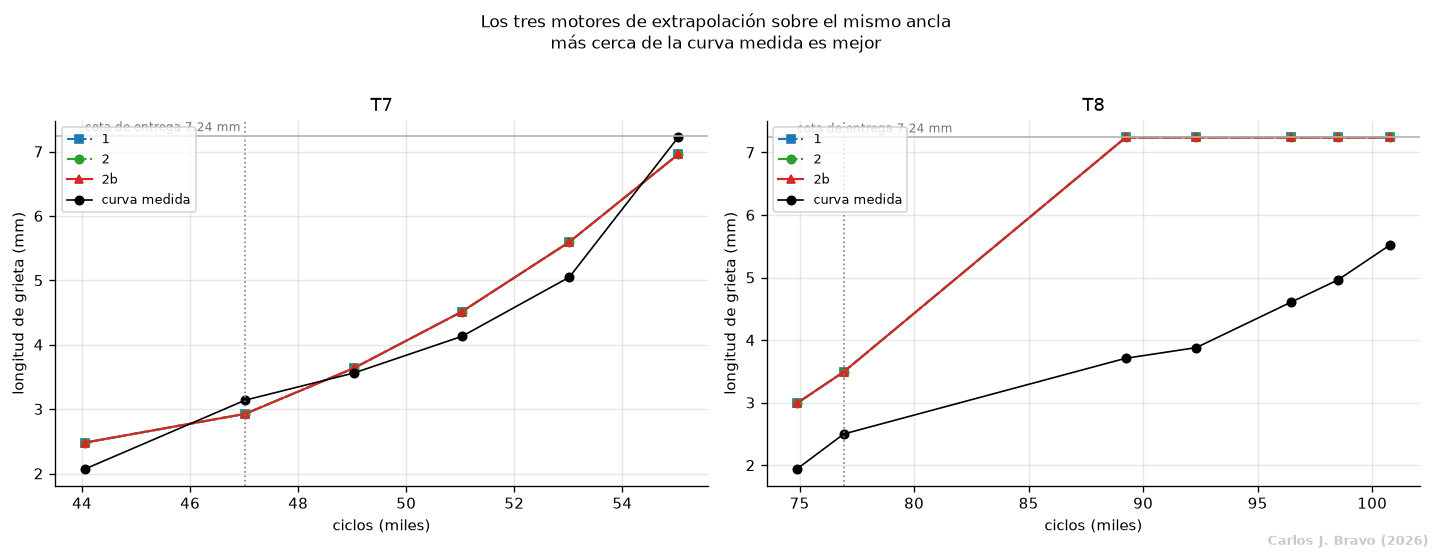

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
ESTILO = {"analítica": dict(color="C0", ls="--", marker="s"),
          "RK4": dict(color="C2", ls="-.", marker="o"),
          "RK4+Wheeler": dict(color="C3", ls="-", marker="^")}
for ax, nombre in zip(axes, ("T7", "T8")):
    cur = anclas[nombre]["curva"]
    ciclos = np.asarray(cur.cycles) / 1e3
    for motor in ESTILO:
        ax.plot(ciclos, resultados[motor][nombre]["pred"], ms=5, lw=1.3,
                label=ETIQ[motor].split()[1], **ESTILO[motor])
    ax.plot(ciclos, cur.crack_mm, "ko-", ms=5, lw=1, label="curva medida")
    ax.axvline(anclas[nombre]["ancla_ciclo"] / 1e3, color="0.5", ls=":", lw=1)
    ax.annotate("último ancla con señal", xy=(anclas[nombre]["ancla_ciclo"] / 1e3, 0),
                xytext=(3, 3), textcoords="offset points", fontsize=7, color="0.45")
    ax.axhline(COTA, color="0.7", lw=1)
    ax.annotate(f"cota de entrega {COTA} mm", xy=(ciclos[0], COTA), xytext=(0, 3),
                textcoords="offset points", fontsize=7, color="0.45")
    ax.set(xlabel="ciclos (miles)", ylabel="longitud de grieta (mm)", title=nombre)
    ax.legend(fontsize=7.5, loc="upper left")
fig.suptitle("Los tres motores de extrapolación sobre el mismo ancla\n"
             "más cerca de la curva medida es mejor", y=1.02, fontsize=10)
marca_de_agua(fig)
fig.tight_layout(); plt.show()

### 5.1 Sensibilidad al exponente del retardo

El barrido recorre el exponente y recalcula la entrega completa con cada valor, sobre el mismo
estimador y el mismo ancla. El intervalo de 1.0 a 3.5 cubre el publicado para otras aleaciones de
aluminio. Los tres últimos valores quedan muy por encima de él y no son candidatos: sirven para
localizar a partir de qué intensidad el retardo llegaría a registrarse en la entrega.

In [8]:
P_PUBLICADO_MAX = 3.5
EXPONENTES_P = (0.0, 1.0, 1.43, 2.0, 2.5, 3.0, 3.5, 10.0, 20.0, 40.0)
filas = []
for p in EXPONENTES_P:
    motor = "RK4" if p == 0.0 else "RK4+Wheeler"
    factor = float(block_rate_with_retardation(3e-3, 1e-9, cfg.m_exponent, bloque_t8, p)
                   / block_rate_with_retardation(3e-3, 1e-9, cfg.m_exponent, bloque_t8, 0.0))
    fila = {"p": p, "desplazamiento (dex)": round(float(np.log10(factor)), 4),
            "dentro del publicado": "sí" if p <= P_PUBLICADO_MAX else "no"}
    for n in ("T7", "T8"):
        fila[f"pen {n}"] = round(entrega(n, motor, p=p)["pen"], 2)
    fila["pen T8 sin la cota"] = round(entrega("T8", motor, p=p, cota=SIN_COTA)["pen"], 2)
    filas.append(fila)
sens = pd.DataFrame(filas)
display(sens)

dentro = sens.loc[sens["dentro del publicado"] == "sí"]
mueve = sens.loc[sens["pen T8"] < sens["pen T8"].iloc[0] - 0.01]
print(f"Dentro del intervalo publicado la penalización de T8 no varía: "
      f"{dentro['pen T8'].min():.2f} en todos los valores.")
print(f"Sin la cota, en cambio, sí varía: de {dentro['pen T8 sin la cota'].iloc[0]:.0f} "
      f"a {dentro['pen T8 sin la cota'].min():.0f}.")
print(f"El primer exponente que mueve la entrega es p = {mueve['p'].min():.0f}, "
      f"muy por encima del intervalo publicado.")

,p,desplazamiento (dex),dentro del publicado,pen T7,pen T8,pen T8 sin la cota
0,0.00,0.0000,sí,6.49,90.45,8289.46
1,1.00,-0.0390,sí,6.49,90.45,7735.00
2,1.43,-0.0542,sí,6.49,90.45,6793.85
3,2.00,-0.0731,sí,6.49,90.45,6103.18
4,2.50,-0.0885,sí,6.49,90.45,5153.87
5,3.00,-0.1028,sí,6.49,90.45,4324.73
6,3.50,-0.1161,sí,6.49,90.45,3811.91
7,10.00,-0.2161,no,6.49,90.26,596.95
8,20.00,-0.2500,no,6.49,86.22,380.77
9,40.00,-0.2546,no,6.49,85.74,360.16


Dentro del intervalo publicado la penalización de T8 no varía: 90.45 en todos los valores.
Sin la cota, en cambio, sí varía: de 8289 a 3812.
El primer exponente que mueve la entrega es p = 10, muy por encima del intervalo publicado.


El barrido separa dos lecturas que conviene no confundir.

Dentro del intervalo publicado para aleaciones de aluminio la penalización de la entrega no varía en
ninguna de las dos probetas. T7 no lo nota porque está sometida a amplitud constante y no tiene
sobrecarga que genere retardo. T8 tampoco, porque todos los desplazamientos del coeficiente que el
exponente llega a producir caen dentro de la franja donde la cota de entrega satura la ventana
ciega.

La última columna levanta la cota y muestra que el retardo no es inerte: sobre la extrapolación sin
recortar sí reduce la penalización de T8, y lo hace de forma creciente con el exponente. Lo que
ocurre es que actúa en un tramo de la curva que la cota ya había eliminado, y que la propia cota
reduce mucho más de lo que el retardo llega a reducir. El apartado 8 pone las dos reducciones en la
misma escala.

## 6. Comparación con la Configuración 1

Ésta es la comparación que el estudio de ablación pide, y su respuesta es un resultado nulo.

In [9]:
filas = []
for motor in ("analítica", "RK4", "RK4+Wheeler"):
    for n in ("T7", "T8"):
        filas.append({
            "variante": ETIQ[motor],
            "espécimen": n,
            "pen sin la cota": round(sin_recorte[motor][n]["pen"], 2),
            "pen en la entrega": round(resultados[motor][n]["pen"], 2),
            "Δ curva sin la cota (mm)": round(float(np.max(np.abs(
                sin_recorte[motor][n]["pred"] - sin_recorte["analítica"][n]["pred"]))), 4),
            "Δ curva en la entrega (mm)": round(float(np.max(np.abs(
                resultados[motor][n]["pred"] - resultados["analítica"][n]["pred"]))), 4),
        })
display(pd.DataFrame(filas))

reduccion_cota = (sin_recorte["analítica"]["T8"]["pen"] - resultados["analítica"]["T8"]["pen"])
reduccion_retardo = (sin_recorte["analítica"]["T8"]["pen"]
                     - sin_recorte["RK4+Wheeler"]["T8"]["pen"])
print(f"Sobre T8 y sin recortar, el retardo reduce la penalización en {reduccion_retardo:.0f} "
      f"puntos, el {100 * reduccion_retardo / sin_recorte['analítica']['T8']['pen']:.0f} %.")
print(f"La cota de entrega, por sí sola, la reduce en {reduccion_cota:.0f} puntos, "
      f"el {100 * reduccion_cota / sin_recorte['analítica']['T8']['pen']:.0f} %.")

,variante,espécimen,pen sin la cota,pen en la entrega,Δ curva sin la cota (mm),Δ curva en la entrega (mm)
0,Config 1 (a+b) forma cerrada,T7,6.49,6.49,0.0000,0.0
1,Config 1 (a+b) forma cerrada,T8,8289.46,90.45,0.0000,0.0
2,Config 2 (a+b+c) integración explícita,T7,6.49,6.49,0.0000,0.0
3,Config 2 (a+b+c) integración explícita,T8,8289.46,90.45,0.0000,0.0
4,"Config 2b (a+b+c*) integración con retardo, p ...",T7,6.49,6.49,0.0000,0.0
5,"Config 2b (a+b+c*) integración con retardo, p ...",T8,6793.85,90.45,2.5006,0.0


Sobre T8 y sin recortar, el retardo reduce la penalización en 1496 puntos, el 18 %.
La cota de entrega, por sí sola, la reduce en 8199 puntos, el 99 %.


La comparación se lee en dos niveles, y son distintos.

**En la entrega, que es lo que puntúa el certamen**, ningún motor se separa de la forma cerrada: la
cota recorta las tres curvas al mismo valor en toda la ventana ciega de T8 y las deja idénticas hasta
la cuarta cifra decimal.

**Sin el recorte**, las dos variantes se comportan de manera opuesta. La integración explícita sigue
dando cero, y no por un defecto: bajo amplitud constante la solución analítica es la solución exacta
de la ecuación, y en T8 la grieta avanza del orden de cinco centésimas de milímetro por bloque,
demasiado poco para que resolver segmento a segmento altere el resultado. Es un resultado nulo
estructural. La variante con retardo, en cambio, separa la curva de T8 y reduce su penalización de
forma apreciable.

Las dos cifras del final delimitan el resultado de esta configuración. El retardo actúa y actúa en la
dirección correcta, pero la cota de entrega, que la Configuración 1 ya incorpora, corrige el mismo
defecto con un margen mucho mayor y deja sin efecto lo que el retardo aportaba. El apartado 8 mide
ambas correcciones en la escala del coeficiente, que es donde son comparables.

## 7. La naturaleza del factor de retardo

Las medidas que siguen delimitan el alcance de la variante 2b.

In [10]:
filas = []
for a_mm in (2.0, 3.0, 4.0, 5.0, 8.0, 15.0):
    a = a_mm / 1000.0
    r_ol = plastic_zone_m(k_max(a, bloque_t8[I_SOBRECARGA, 1]))
    r_y = plastic_zone_m(k_max(a, bloque_t8[1 - I_SOBRECARGA, 1]))
    filas.append({
        "a (mm)": a_mm,
        "phi": float(wheeler_phi(a, a, r_ol, r_y, WHEELER_P)),
        "tasa retardada / sin retardo": float(
            block_rate_with_retardation(a, 1e-9, cfg.m_exponent, bloque_t8, WHEELER_P)
            / block_rate_with_retardation(a, 1e-9, cfg.m_exponent, bloque_t8, 0.0)),
    })
diag = pd.DataFrame(filas)
display(diag.round(6))

FACTOR_WHEELER = float(diag["tasa retardada / sin retardo"].iloc[0])
DESPLAZAMIENTO_WHEELER = float(np.log10(FACTOR_WHEELER))
print(f"phi varía entre {diag['phi'].min():.6f} y {diag['phi'].max():.6f} "
      f"en todo el rango tabulado.")
print(f"La integración con retardo coincide con integrar usando C x {FACTOR_WHEELER:.5f},")
print(f"equivalente a desplazar log10 C en {DESPLAZAMIENTO_WHEELER:+.4f} dex.")

,a (mm),phi,tasa retardada / sin retardo
0,2.0,0.735407,0.882609
1,3.0,0.735407,0.882609
2,4.0,0.735407,0.882609
3,5.0,0.735407,0.882609
4,8.0,0.735407,0.882609
5,15.0,0.735407,0.882609


phi varía entre 0.735407 y 0.735407 en todo el rango tabulado.
La integración con retardo coincide con integrar usando C x 0.88261,
equivalente a desplazar log10 C en -0.0542 dex.


Que el factor de retardo no dependa de la longitud de grieta significa que no hay efecto de historia:
la punta nunca sale de la zona plástica dentro del rango de interés, porque la sobrecarga se reevalúa
en cada bloque. El retardo se reduce entonces a una constante multiplicativa sobre el coeficiente de
la ley de crecimiento.

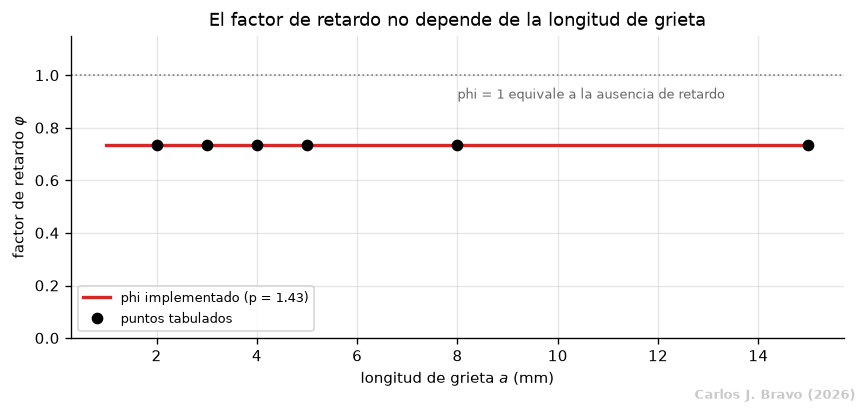

In [11]:
a_barrido = np.linspace(1.0, 15.0, 60)
phi = [float(wheeler_phi(a/1000.0, a/1000.0,
                         plastic_zone_m(k_max(a/1000.0, bloque_t8[:, 1].max())),
                         plastic_zone_m(k_max(a/1000.0, bloque_t8[:, 1].min())),
                         WHEELER_P)) for a in a_barrido]

fig, ax = plt.subplots(figsize=(7.2, 3.4))
ax.plot(a_barrido, phi, color="C3", lw=2, label=f"phi implementado (p = {WHEELER_P})")
ax.plot(diag["a (mm)"], diag["phi"], "ko", ms=6, label="puntos tabulados")
ax.axhline(1.0, color="0.5", ls=":", lw=1)
ax.annotate("phi = 1 equivale a la ausencia de retardo", xy=(8, 1.0), xytext=(0, -14),
            textcoords="offset points", fontsize=7.5, color="0.4")
ax.set(xlabel="longitud de grieta $a$ (mm)", ylabel=r"factor de retardo $\varphi$",
       ylim=(0, 1.15),
       title="El factor de retardo no depende de la longitud de grieta")
ax.legend(fontsize=8)
marca_de_agua(fig)
fig.tight_layout(); plt.show()

La curva plana es la lectura gráfica de ese mismo hecho: el factor sería creciente si la punta fuese
saliendo de la zona plástica que dejó la sobrecarga.

In [12]:
peso = bloque_t8[:, 0] / bloque_t8[:, 0].sum()
tasa_relativa = (bloque_t8[:, 1] - bloque_t8[:, 2]) ** cfg.m_exponent
FACTOR_TECHO = float(peso[I_SOBRECARGA] * tasa_relativa[I_SOBRECARGA] / float((peso * tasa_relativa).sum()))
DESPLAZAMIENTO_TECHO = float(np.log10(FACTOR_TECHO))
factor_extremo = float(
    block_rate_with_retardation(3e-3, 1e-9, cfg.m_exponent, bloque_t8, P_PUBLICADO_MAX)
    / block_rate_with_retardation(3e-3, 1e-9, cfg.m_exponent, bloque_t8, 0.0))

print(f"Retardo con p = {WHEELER_P}                          : "
      f"x{1/FACTOR_WHEELER:.3f}  ({DESPLAZAMIENTO_WHEELER:+.4f} dex)")
print(f"Retardo en el extremo del intervalo publicado, p = {P_PUBLICADO_MAX} : "
      f"x{1/factor_extremo:.3f}  ({np.log10(factor_extremo):+.4f} dex)")
print(f"Techo estructural del retardo en este bloque : "
      f"x{1/FACTOR_TECHO:.3f}  ({DESPLAZAMIENTO_TECHO:+.4f} dex)")

Retardo con p = 1.43                          : x1.133  (-0.0542 dex)
Retardo en el extremo del intervalo publicado, p = 3.5 : x1.306  (-0.1161 dex)
Techo estructural del retardo en este bloque : x1.797  (-0.2547 dex)


El segmento de mayor amplitud es la sobrecarga, de modo que nunca se retarda y aporta su tasa
completa en cualquier caso. Aunque la primera mitad del bloque se frenase por completo, la tasa media
sólo podría caer hasta la contribución de esa segunda mitad, y ahí está el techo estructural del
modelo. El apartado siguiente contrasta ese techo con la corrección que T8 realmente necesita.

## 8. El alcance del retardo frente a lo que T8 necesita

El apartado anterior establece que el retardo actúa como un desplazamiento constante del coeficiente
de la ley de crecimiento. Eso permite medirlo en la misma escala en la que se mide lo que a T8 le
falta: se recorre el coeficiente de extrapolación, se reconstruye la entrega completa con cada valor
y se puntúa con la penalización oficial. Todo lo demás, estimador, ancla y cota de entrega, queda
fijo.

In [13]:
rejilla = np.round(np.arange(-9.60, -7.999, 0.005), 4)
barrido_c = pd.DataFrame({
    "log10 C": rejilla,
    "desplazamiento (dex)": np.round(rejilla - anclas["T8"]["log_c"], 4),
    "pen T8": [round(entrega("T8", "analítica", log_c=v)["pen"], 3) for v in rejilla],
})

PEN_BASE = resultados["analítica"]["T8"]["pen"]
OBJETIVO = REPLICA["3.º Rao et al. (2020)"]["T8"]
plano = barrido_c.loc[np.isclose(barrido_c["pen T8"], PEN_BASE, atol=0.01)]
gana = barrido_c.loc[barrido_c["pen T8"] < OBJETIVO]
optimo = barrido_c.loc[barrido_c["pen T8"].idxmin()]
UMBRAL_PLANO = float(plano["desplazamiento (dex)"].min())

resumen = pd.DataFrame([
    {"magnitud": "coeficiente identificado por el modelo", "dex": 0.0,
     "log10 C": round(float(anclas["T8"]["log_c"]), 3), "pen T8": round(PEN_BASE, 2)},
    {"magnitud": f"retardo con p = {WHEELER_P}", "dex": round(DESPLAZAMIENTO_WHEELER, 3),
     "log10 C": round(float(anclas["T8"]["log_c"]) + DESPLAZAMIENTO_WHEELER, 3),
     "pen T8": round(resultados["RK4+Wheeler"]["T8"]["pen"], 2)},
    {"magnitud": "techo estructural del retardo", "dex": round(DESPLAZAMIENTO_TECHO, 3),
     "log10 C": round(float(anclas["T8"]["log_c"]) + DESPLAZAMIENTO_TECHO, 3),
     "pen T8": round(float(entrega("T8", "analítica",
                                   log_c=anclas["T8"]["log_c"] + DESPLAZAMIENTO_TECHO)["pen"]), 2)},
    {"magnitud": "umbral a partir del cual la cota deja de saturar",
     "dex": round(UMBRAL_PLANO, 3),
     "log10 C": round(float(anclas["T8"]["log_c"]) + UMBRAL_PLANO, 3),
     "pen T8": round(PEN_BASE, 2)},
    {"magnitud": "coeficiente implicado por la curva de T8",
     "dex": round(float(anclas["T8"]["log_c_oraculo"] - anclas["T8"]["log_c"]), 3),
     "log10 C": round(float(anclas["T8"]["log_c_oraculo"]), 3),
     "pen T8": round(float(entrega("T8", "analítica",
                                   log_c=anclas["T8"]["log_c_oraculo"])["pen"]), 2)},
    {"magnitud": "coeficiente que minimiza la penalización",
     "dex": round(float(optimo["desplazamiento (dex)"]), 3),
     "log10 C": round(float(optimo["log10 C"]), 3), "pen T8": round(float(optimo["pen T8"]), 2)},
])
display(resumen)

print(f"La cota de entrega satura la ventana ciega y deja la penalización en {PEN_BASE:.2f} "
      f"para todo desplazamiento menor que {abs(UMBRAL_PLANO):.3f} dex.")
print(f"Para bajar de {OBJETIVO:.2f}, que es la réplica del tercer clasificado, hace falta un "
      f"desplazamiento entre {gana['desplazamiento (dex)'].max():.3f} y "
      f"{gana['desplazamiento (dex)'].min():.3f} dex.")
print(f"El retardo entrega {DESPLAZAMIENTO_WHEELER:.3f} dex y su techo estructural, "
      f"{DESPLAZAMIENTO_TECHO:.3f} dex.")

,magnitud,dex,log10 C,pen T8
0,coeficiente identificado por el modelo,0.000,-8.423,90.45
1,retardo con p = 1.43,-0.054,-8.477,90.45
2,techo estructural del retardo,-0.255,-8.678,85.74
3,umbral a partir del cual la cota deja de saturar,-0.212,-8.635,90.45
4,coeficiente implicado por la curva de T8,-0.380,-8.803,70.25
5,coeficiente que minimiza la penalización,-0.712,-9.135,14.34


La cota de entrega satura la ventana ciega y deja la penalización en 90.45 para todo desplazamiento menor que 0.212 dex.
Para bajar de 25.79, que es la réplica del tercer clasificado, hace falta un desplazamiento entre -0.612 y -0.877 dex.
El retardo entrega -0.054 dex y su techo estructural, -0.255 dex.


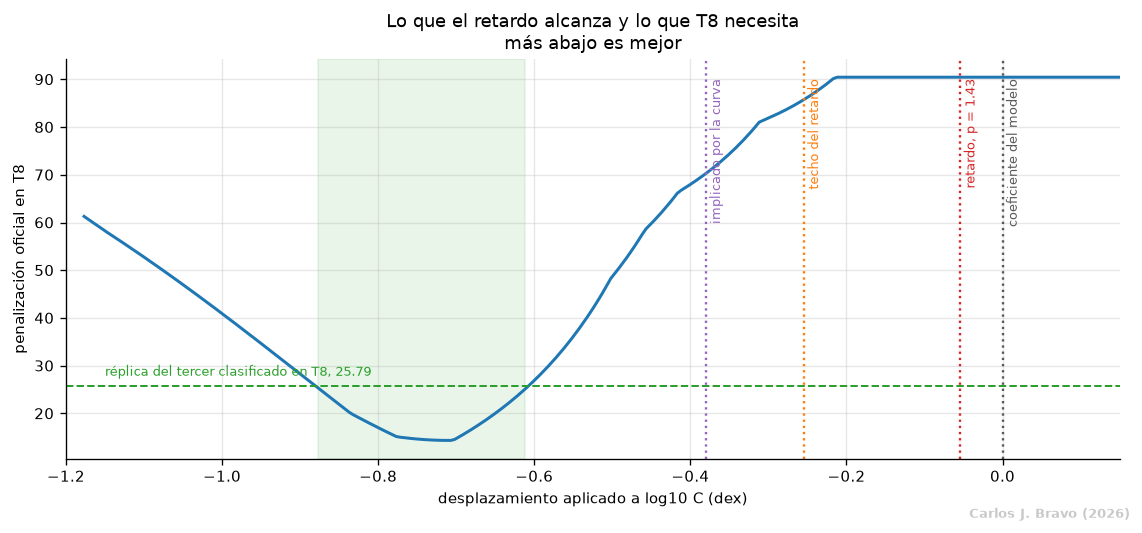

In [14]:
fig, ax = plt.subplots(figsize=(9.5, 4.4))
ax.plot(barrido_c["desplazamiento (dex)"], barrido_c["pen T8"], color="C0", lw=1.8)
ax.axhline(OBJETIVO, color="C2", ls="--", lw=1.2)
ax.annotate(f"réplica del tercer clasificado en T8, {OBJETIVO:.2f}",
            xy=(-1.15, OBJETIVO), xytext=(0, 6), textcoords="offset points",
            fontsize=8, color="C2")
ax.axvspan(float(gana["desplazamiento (dex)"].min()), float(gana["desplazamiento (dex)"].max()),
           color="C2", alpha=0.10)
for x, etiqueta, color in (
        (0.0, "coeficiente del modelo", "0.35"),
        (DESPLAZAMIENTO_WHEELER, f"retardo, p = {WHEELER_P}", "C3"),
        (DESPLAZAMIENTO_TECHO, "techo del retardo", "C1"),
        (float(anclas["T8"]["log_c_oraculo"] - anclas["T8"]["log_c"]), "implicado por la curva", "C4")):
    ax.axvline(x, color=color, ls=":", lw=1.4)
    ax.annotate(etiqueta, xy=(x, ax.get_ylim()[1]), xytext=(2, -12), rotation=90,
                textcoords="offset points", fontsize=7.5, color=color, va="top")
ax.set(xlabel="desplazamiento aplicado a log10 C (dex)",
       ylabel="penalización oficial en T8",
       xlim=(-1.2, 0.15),
       title="Lo que el retardo alcanza y lo que T8 necesita\nmás abajo es mejor")
marca_de_agua(fig)
fig.tight_layout(); plt.show()

La lectura es directa. La cota de entrega recorta la extrapolación a la longitud de grieta máxima que
los especímenes de entrenamiento respaldan. Mientras la curva extrapolada siga por encima de esa
cota, el coeficiente no influye en la entrega y la penalización permanece en su valor de partida. El
desplazamiento que el retardo produce cae dentro de esa franja, y por eso la variante 2b entrega
exactamente la misma penalización que la forma cerrada aunque su curva sin recortar sea distinta.

El techo estructural del modelo sí rebasa el umbral, pero apenas: rebaja la penalización de T8 en
torno a cinco puntos sobre noventa, y sigue quedando lejos de la franja de coeficientes que batiría a
la réplica del tercer clasificado. Esa franja pide un desplazamiento entre dos y tres veces mayor que
el máximo que el modelo puede producir, y hacen falta exponentes muy por encima del intervalo
publicado incluso para llegar al umbral.

La causa es la estructura del bloque de carga y no el valor del exponente. El segmento de mayor
amplitud es la sobrecarga, nunca se retarda y aporta la mayor parte de la tasa media, de modo que
frenar el segmento restante no puede reducir el conjunto más allá de la contribución de aquél. Esto
delimita lo que el componente añadido puede reivindicar: reproduce el signo de la corrección que T8
necesita y una fracción de su magnitud, pero la restricción de dominio que la Configuración 1 ya
aplica cubre ese mismo defecto con un margen mucho mayor. También delimita dónde habría que buscar la
magnitud que falta, que es en un mecanismo capaz de actuar sobre los dos segmentos del bloque y no
sólo sobre el de menor amplitud.

### 8.1 El límite del componente añadido

Las medidas anteriores dependen del exponente adoptado. La que sigue no. El exponente se lleva hasta
donde deja de producir efecto, muy por encima de cualquier valor con respaldo, de modo que la tabla
describe el mejor resultado que la variante 2b podría alcanzar aunque su parámetro se eligiese
mirando directamente a la probeta de evaluación. Es la cota superior del componente añadido.

In [15]:
EXPONENTES_LIMITE = (0.0, 0.94, 1.43, 2.19, 3.5, 5.0, 8.0, 10.0, 15.0, 20.0, 30.0, 50.0, 100.0, 1000.0)
filas = []
for p in EXPONENTES_LIMITE:
    motor = "RK4" if p == 0.0 else "RK4+Wheeler"
    factor = float(block_rate_with_retardation(3e-3, 1e-9, cfg.m_exponent, bloque_t8, p)
                   / block_rate_with_retardation(3e-3, 1e-9, cfg.m_exponent, bloque_t8, 0.0))
    filas.append({
        "p": p,
        "desplazamiento (dex)": round(float(np.log10(factor)), 4),
        "pen T8": round(entrega("T8", motor, p=p)["pen"], 2),
        "pen T8 sin la cota": round(entrega("T8", motor, p=p, cota=SIN_COTA)["pen"], 2),
    })
limite = pd.DataFrame(filas)
display(limite)

PEN_LIMITE = float(limite["pen T8"].min())
PEN_OPTIMO_COEF = float(optimo["pen T8"])
print(f"La penalización decrece de forma monótona con el exponente y satura en {PEN_LIMITE:.2f}.")
print("No hay un valor óptimo interior: el mejor resultado es el del límite, que corresponde a")
print("frenar por completo el segmento de menor amplitud del bloque.\n")
print(f"  mejor resultado posible del retardo        : {PEN_LIMITE:8.2f}")
print(f"  réplica del tercer clasificado en T8       : {OBJETIVO:8.2f}")
print(f"  óptimo alcanzable ajustando el coeficiente : {PEN_OPTIMO_COEF:8.2f}")
print(f"\nEl mejor resultado del retardo queda {PEN_LIMITE/OBJETIVO:.1f} veces por encima de la "
      f"réplica\ny {PEN_LIMITE/PEN_OPTIMO_COEF:.1f} veces por encima del óptimo por coeficiente.")

,p,desplazamiento (dex),pen T8,pen T8 sin la cota
0,0.00,0.0000,90.45,8289.46
1,0.94,-0.0368,90.45,7914.12
2,1.43,-0.0542,90.45,6793.85
3,2.19,-0.0791,90.45,5941.66
4,3.50,-0.1161,90.45,3811.91
5,5.00,-0.1501,90.45,1901.92
6,8.00,-0.1967,90.45,802.10
7,10.00,-0.2161,90.26,596.95
8,15.00,-0.2411,87.17,425.31
9,20.00,-0.2500,86.22,380.77


La penalización decrece de forma monótona con el exponente y satura en 85.74.
No hay un valor óptimo interior: el mejor resultado es el del límite, que corresponde a
frenar por completo el segmento de menor amplitud del bloque.

  mejor resultado posible del retardo        :    85.74
  réplica del tercer clasificado en T8       :    25.79
  óptimo alcanzable ajustando el coeficiente :    14.34

El mejor resultado del retardo queda 3.3 veces por encima de la réplica
y 6.0 veces por encima del óptimo por coeficiente.


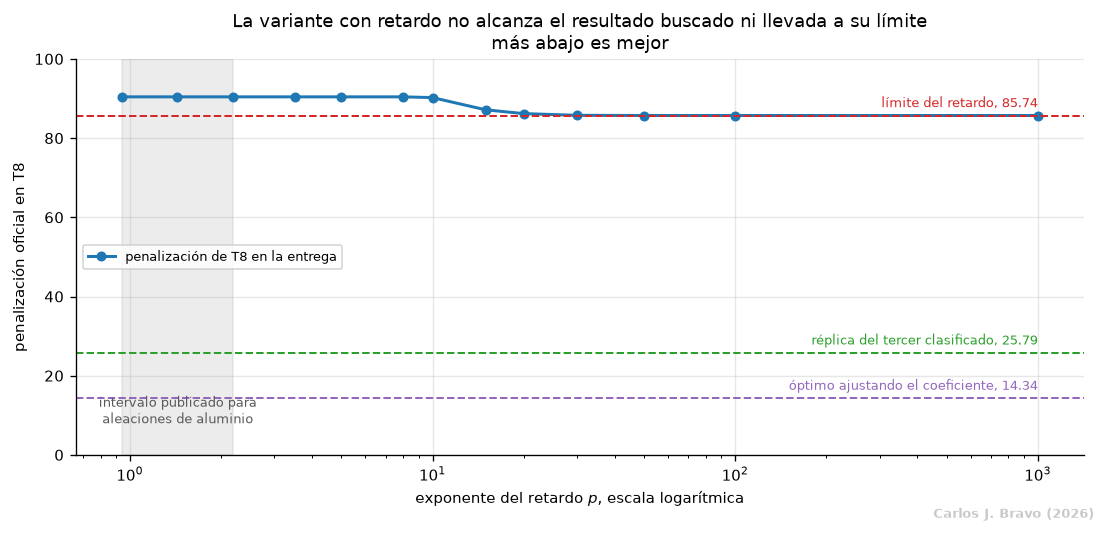

In [16]:
fig, ax = plt.subplots(figsize=(9.2, 4.4))
positivos = limite.loc[limite["p"] > 0]
ax.plot(positivos["p"], positivos["pen T8"], "o-", color="C0", lw=1.8, ms=5,
        label="penalización de T8 en la entrega")
ax.axvspan(0.94, 2.19, color="0.55", alpha=0.16)
ax.annotate("intervalo publicado para\naleaciones de aluminio", xy=(1.44, 8), fontsize=7.5,
            color="0.35", ha="center")
for y, etiqueta, color in (
        (PEN_LIMITE, f"límite del retardo, {PEN_LIMITE:.2f}", "C3"),
        (OBJETIVO, f"réplica del tercer clasificado, {OBJETIVO:.2f}", "C2"),
        (PEN_OPTIMO_COEF, f"óptimo ajustando el coeficiente, {PEN_OPTIMO_COEF:.2f}", "C4")):
    ax.axhline(y, color=color, ls="--", lw=1.2)
    ax.annotate(etiqueta, xy=(1000, y), xytext=(0, 5), textcoords="offset points",
                fontsize=8, color=color, ha="right")
ax.set(xscale="log", xlabel="exponente del retardo $p$, escala logarítmica",
       ylabel="penalización oficial en T8", ylim=(0, 100),
       title="La variante con retardo no alcanza el resultado buscado ni llevada a su límite\n"
             "más abajo es mejor")
ax.legend(fontsize=8, loc="center left")
marca_de_agua(fig)
fig.tight_layout(); plt.show()

La demostración se cierra aquí. La variante 2b no es viable como componente del pronóstico y tampoco
mejora al modelo base, y ninguna de las dos afirmaciones depende del exponente adoptado.

No es viable porque su único parámetro no puede determinarse con estos datos: el retardo sólo deja
huella bajo amplitud variable y el único espécimen de ese régimen es el de evaluación. No mejora al
modelo porque, dentro del intervalo publicado para aleaciones de aluminio, la entrega es idéntica a
la de la forma cerrada en las dos probetas, y porque llevando el exponente hasta el límite en que
deja de producir efecto la penalización de T8 se queda en un valor que sigue estando muy por encima
de la réplica del tercer clasificado y del óptimo alcanzable corrigiendo el coeficiente.

El límite es estructural y admite una lectura física directa. El segmento de mayor amplitud del
bloque es la sobrecarga, nunca se retarda y aporta la mayor parte de la tasa media, de modo que
frenar el segmento restante, incluso por completo, no puede reducir la tasa del bloque más allá de
la contribución de aquél. Un mecanismo con la magnitud que T8 necesita tendría que actuar sobre los
dos segmentos, lo que excluye a los modelos de retardo basados en la zona plástica de la sobrecarga.

## 9. Conclusiones

1. **La integración explícita, por sí sola, no aporta nada.** La diferencia frente a la forma cerrada
   es nula hasta la cuarta cifra decimal, y lo sigue siendo al levantar la cota de entrega. Es un
   resultado nulo estructural: bajo amplitud constante la forma cerrada ya es la solución exacta, y
   en T8 el avance por bloque es demasiado pequeño para que la resolución segmento a segmento cambie
   nada. En un estudio de ablación la fila que no mejora es tan informativa como la que sí.
2. **El retardo sí actúa, y en la dirección correcta.** Sobre la extrapolación sin recortar reduce la
   penalización de T8 de forma apreciable y creciente con el exponente. No es un componente inerte.
3. **Lo que actúa queda subsumido por la restricción de dominio.** La cota de entrega que la
   Configuración 1 ya aplica corrige el mismo defecto, la divergencia de la extrapolación en T8, con
   un margen muy superior, y deja sin efecto la reducción que el retardo aportaba. Las tres variantes
   entregan la misma penalización por espécimen.
4. **El retardo modelado no produce efecto de historia.** El factor de retardo es constante en todo
   el rango de longitudes de grieta de interés, de modo que la integración con retardo coincide
   exactamente con integrar usando un coeficiente desplazado. Es una recalibración del coeficiente y
   no un modelo de interacción de cargas.
5. **La recalibración no alcanza, y el límite es estructural.** El desplazamiento que el retardo
   entrega queda por debajo del umbral a partir del cual la cota deja de saturar la ventana ciega. El
   techo del modelo, que corresponde a frenar por completo el segmento de menor amplitud, rebasa ese
   umbral por poco y no se acerca a la franja de coeficientes que batiría a la réplica del tercer
   clasificado.
6. **El exponente del retardo no es determinable con estos datos**, porque sólo deja huella bajo
   amplitud variable y el único espécimen de ese régimen es el de evaluación. El valor empleado
   procede de la literatura sobre un acero y queda dentro del intervalo publicado para otras
   aleaciones de aluminio, pero no hay ninguno publicado para el 2024-T3.
7. **La variante con retardo no es viable ni mejora al modelo base, y la conclusión no depende del
   exponente.** Dentro del intervalo publicado la entrega es idéntica a la de la forma cerrada en
   las dos probetas. Llevando el exponente hasta el límite en que deja de producir efecto, que está
   muy por encima de cualquier valor con respaldo, la penalización de T8 satura en un valor que
   sigue quedando muy por encima de la réplica del tercer clasificado y del óptimo alcanzable
   corrigiendo el coeficiente. El apartado 8.1 recoge la medida.

## 10. Limitaciones

* El valor *p* = 1.43 procede de la literatura sobre un acero. No hay ninguno publicado para el
  2024-T3, y el intervalo que se toma como referencia corresponde a otras aleaciones de aluminio.
  Los valores que los barridos recorren por encima de ese intervalo carecen de respaldo y se
  presentan únicamente para acotar el límite del mecanismo.
* Ningún espécimen de entrenamiento es de amplitud variable, de modo que el exponente del retardo no
  puede determinarse a partir de los datos y la interacción de cargas no puede validarse.
* La cota de entrega, heredada de la Configuración 1, fija la magnitud de la curva entregada en T8
  mientras el coeficiente permanezca por encima del umbral medido en el apartado 8. Ordenar variantes
  por su penalización en T8 dentro de esa franja ordena dónde cae el recorte y no la calidad del
  motor, y es la razón por la que este cuaderno reporta también la evaluación sin recorte.
* La sobrecarga se reevalúa en cada bloque, lo que elimina el efecto de historia que el modelo
  pretende capturar.

## Los pesos entrenados

Los conjuntos que este cuaderno ha usado quedan guardados en `models/`, de modo que una ejecución
posterior los carga en lugar de repetir el entrenamiento. Como la siembra está fijada, cargar y
reentrenar producen los mismos pesos bit a bit; lo que cambia es el tiempo.


In [ ]:
print(inventario())
